In [14]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point
from scipy.spatial import cKDTree
import xarray as xr


import shapely.geometry as geom

from shapely.ops import nearest_points
import tqdm

**Archivos**:

chlorophyll.nc

nitrate.nc

oxygen_dissolved.nc

oxygen_utilization.nc

phosphate.nc

salinity.nc

temperature_celsius.nc

distance_to_coastline.shp

#### Crear grilla ocean en blanco

In [15]:
# Crear la grilla 0.5° × 0.5°
lats = np.arange(-89.5, 90, 0.5)   # centro de celda
lons = np.arange(-179.5, 180, 0.5)
grid_list = []

for lat in lats:
    for lon in lons:
        grid_list.append({'lat': lat, 'lon': lon})

grid = pd.DataFrame(grid_list)

# Convertir a GeoDataFrame
grid_gdf = gpd.GeoDataFrame(grid, geometry=gpd.points_from_xy(grid.lon, grid.lat))
grid_gdf.set_crs(epsg=4326, inplace=True)

,lat,lon,geometry
0,-89.5,-179.5,POINT (-179.5 -89.5)
1,-89.5,-179.0,POINT (-179 -89.5)
2,-89.5,-178.5,POINT (-178.5 -89.5)
3,-89.5,-178.0,POINT (-178 -89.5)
4,-89.5,-177.5,POINT (-177.5 -89.5)
...,...,...,...
258116,89.5,177.5,POINT (177.5 89.5)
258117,89.5,178.0,POINT (178 89.5)
258118,89.5,178.5,POINT (178.5 89.5)
258119,89.5,179.0,POINT (179 89.5)


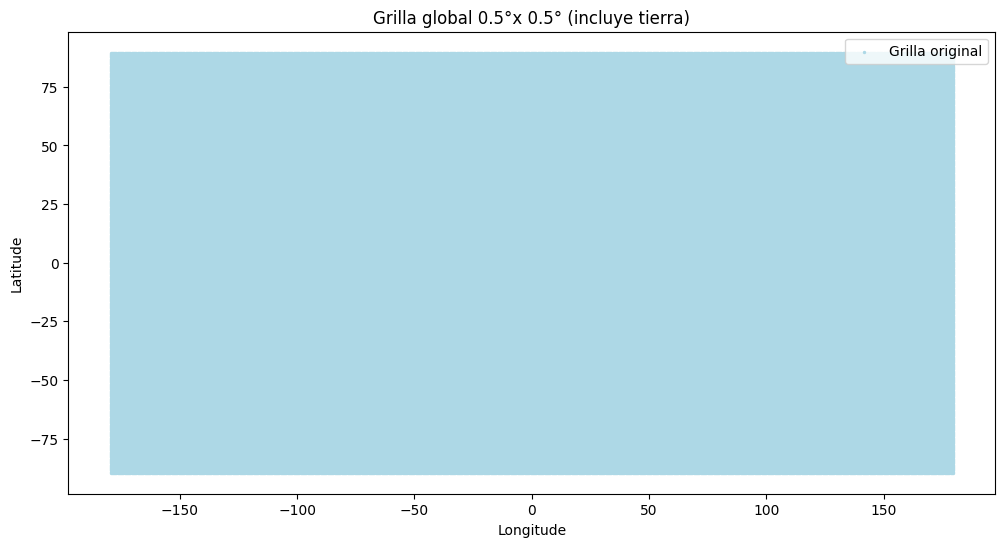

In [16]:
# Visualización inicial
# Mapa de toda la grilla (grid_gdf)

fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid_gdf.plot(ax=ax, color='lightblue', markersize=2, label='Grilla original')
ax.set_title("Grilla global 0.5°x 0.5° (incluye tierra)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

In [17]:
# Cargar shapefile de land
land = gpd.read_file("../data/ocean/land.shp").to_crs(epsg=4326)

# Convertir grid a GeoDataFrame si no lo es
grid_gdf['geometry'] = [Point(xy) for xy in zip(grid_gdf.lon, grid_gdf.lat)]

# Hacer spatial join: quedarnos solo con puntos que NO están en land
grid_water = grid_gdf[~grid_gdf.geometry.apply(lambda p: land.contains(p).any())].copy()

print(f"Antes: {len(grid_gdf)} celdas, Después (solo agua): {len(grid_water)} celdas")


Antes: 258121 celdas, Después (solo agua): 172729 celdas


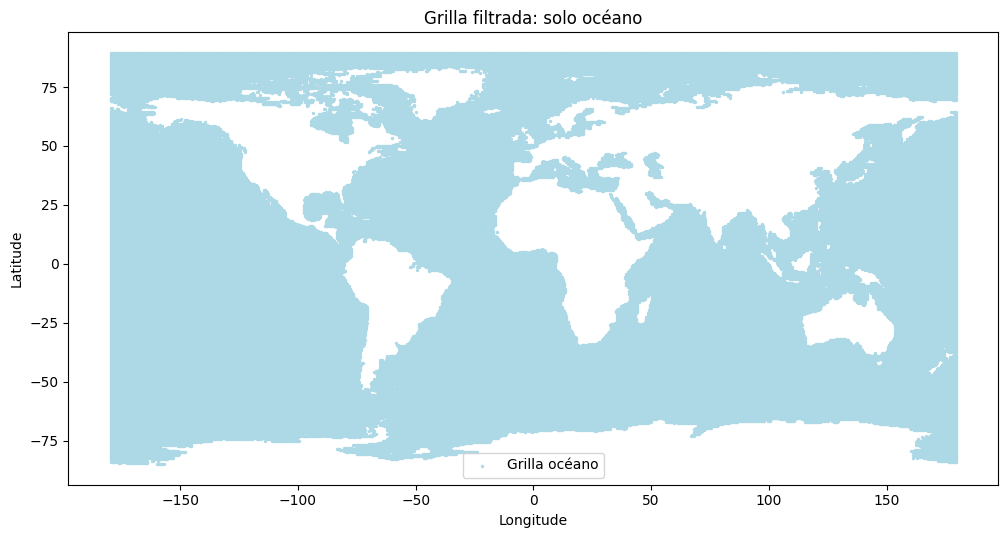

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid_water.plot(ax=ax, color='lightblue', markersize=2, label='Grilla océano')
ax.set_title("Grilla filtrada: solo océano")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

#### Calcular distancia a la costa (variable)

In [22]:
# Cargar shapefile de costa y calcular distance_to_coast_km 

coast = gpd.read_file("../data/ocean/distance_to_coastline.shp").to_crs(epsg=4326)
grid_water = grid_water.to_crs(epsg=4326)

# Extraer todos los vértices de la costa
coast_points_list = []

for g in coast.geometry:
    if g is None or g.is_empty:
        continue
    # Polygon
    if g.type == "Polygon":
        coast_points_list.append(np.array(g.exterior.coords))
    # MultiPolygon
    elif g.type == "MultiPolygon":
        for poly in g.geoms:
            coast_points_list.append(np.array(poly.exterior.coords))
    # LineString
    elif g.type == "LineString":
        coast_points_list.append(np.array(g.coords))
    # MultiLineString
    elif g.type == "MultiLineString":
        for line in g.geoms:
            coast_points_list.append(np.array(line.coords))

if not coast_points_list:
    raise ValueError("No se encontraron puntos de costa válidos en el shapefile.")

# Combinar todos los puntos
coast_points = np.vstack(coast_points_list)

# Construir KDTree
tree = cKDTree(coast_points)

# Coordenadas de la grilla
coords = np.column_stack([grid_water['lon'], grid_water['lat']])

# Calcular distancia mínima
print("Calculando distance_to_coast_km con KDTree...")
distances_deg, _ = tree.query(coords)

# Convertir grados a km (aprox.)
grid_water['distance_to_coast_km'] = distances_deg * 111

/tmp/ipykernel_4824/8553261.py:13: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if g.type == "Polygon":
/tmp/ipykernel_4824/8553261.py:16: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif g.type == "MultiPolygon":
/tmp/ipykernel_4824/8553261.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif g.type == "LineString":


Calculando distance_to_coast_km con KDTree...


#### Introducir variable oceanográficas restantes

In [23]:
# Extraer variables ambientales desde NetCDF
# -------------------------
def sample_nc_to_points(nc_path, var_name, coords, depth_slice=None):
    ds = xr.open_dataset(nc_path, decode_times=False)
    da = ds[var_name]
    
    # Promediar dimensiones extra
    extra_dims = [d for d in da.dims if d.lower() not in ["lat","latitude","lon","longitude"]]
    if extra_dims:
        da = da.mean(extra_dims)
    
    lat_name = [d for d in da.dims if d.lower() in ["lat","latitude"]][0]
    lon_name = [d for d in da.dims if d.lower() in ["lon","longitude"]][0]
    
    lats = da[lat_name].values
    lons = da[lon_name].values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    values = da.values.flatten()
    
    tree = cKDTree(np.column_stack([lon_grid.flatten(), lat_grid.flatten()]))
    _, idx = tree.query(coords)
    return values[idx]

nc_files = {
    'temperature': ('../data/ocean/temperature_celsius.nc', 't_an'),
    'salinity': ('../data/ocean/salinity.nc', 's_an'),
    'chlorophyll': ('../data/ocean/chlorophyll.nc', 'trend'),
    'nitrate': ('../data/ocean/nitrate.nc', 'n_an'),
    'phosphate': ('../data/ocean/phosphate.nc', 'p_an'),
    'oxygen_dissolved': ('../data/ocean/oxygen_dissolved.nc', 'o_an'),
    'oxygen_utilization': ('../data/ocean/oxygen_utilization.nc', 'A_an')
}

for var, (file, nc_var) in nc_files.items():
    print(f"Extrayendo {var}...")
    grid_water[var] = sample_nc_to_points(file, nc_var, coords)


Extrayendo temperature...
Extrayendo salinity...
Extrayendo chlorophyll...
Extrayendo nitrate...
Extrayendo phosphate...
Extrayendo oxygen_dissolved...
Extrayendo oxygen_utilization...


In [24]:
grid_water.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 172729 entries, 6510 to 258120
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   lat                   172729 non-null  float64 
 1   lon                   172729 non-null  float64 
 2   geometry              172729 non-null  geometry
 3   distance_to_coast_km  172729 non-null  float64 
 4   temperature           162750 non-null  float32 
 5   salinity              162750 non-null  float32 
 6   chlorophyll           131108 non-null  float32 
 7   nitrate               162750 non-null  float32 
 8   phosphate             162750 non-null  float32 
 9   oxygen_dissolved      162750 non-null  float32 
 10  oxygen_utilization    162750 non-null  float32 
dtypes: float32(7), float64(3), geometry(1)
memory usage: 11.2 MB


In [25]:
grid_clean = grid_water.dropna()
grid_clean.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 127013 entries, 16545 to 232651
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   lat                   127013 non-null  float64 
 1   lon                   127013 non-null  float64 
 2   geometry              127013 non-null  geometry
 3   distance_to_coast_km  127013 non-null  float64 
 4   temperature           127013 non-null  float32 
 5   salinity              127013 non-null  float32 
 6   chlorophyll           127013 non-null  float32 
 7   nitrate               127013 non-null  float32 
 8   phosphate             127013 non-null  float32 
 9   oxygen_dissolved      127013 non-null  float32 
 10  oxygen_utilization    127013 non-null  float32 
dtypes: float32(7), float64(3), geometry(1)
memory usage: 8.2 MB


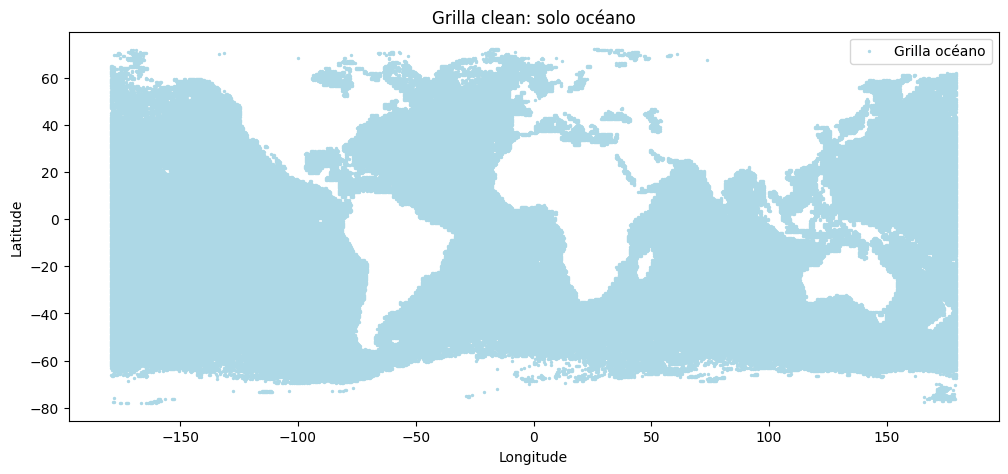

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid_clean.plot(ax=ax, color='lightblue', markersize=2, label='Grilla océano')
ax.set_title("Grilla clean: solo océano")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

In [27]:
grid_clean

,lat,lon,geometry,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization
16545,-78.0,-175.5,POINT (-175.5 -78),543.707048,-1.775068,34.395912,1.680748,27.419722,1.907441,311.153168,59.152695
16546,-78.0,-175.0,POINT (-175 -78),533.294654,-1.775068,34.395912,1.243596,27.419722,1.907441,311.153168,59.152695
16550,-78.0,-173.0,POINT (-173 -78),543.143622,-1.808737,34.373737,-0.760849,27.574869,1.912899,312.213226,57.888039
16551,-78.0,-172.5,POINT (-172.5 -78),540.559218,-1.808737,34.373737,-0.805667,27.574869,1.912899,312.213226,57.888039
16552,-78.0,-172.0,POINT (-172 -78),535.905487,-1.808737,34.373737,-0.708566,27.574869,1.912899,312.213226,57.888039
...,...,...,...,...,...,...,...,...,...,...,...
232566,72.0,-15.0,POINT (-15 72),425.634963,0.289420,34.764435,0.504466,11.316046,0.823883,318.571198,32.765865
232647,72.0,25.5,POINT (25.5 72),94.266326,6.833642,34.894951,0.065487,6.138589,0.608244,298.023193,4.414944
232649,72.0,26.5,POINT (26.5 72),110.341777,6.723017,34.888157,0.365244,5.862425,0.607004,298.572815,4.962784
232650,72.0,27.0,POINT (27 72),111.642511,6.723017,34.888157,-0.597254,5.862425,0.607004,298.572815,4.962784


In [28]:
grid_clean.to_file("../data/grid_ocean/grilla_agua.gpkg", driver="GPKG")
# Solo columnas numéricas
grid_clean.drop(columns='geometry').to_parquet("../data/grid_ocean/grilla_agua.parquet", index=False)
print("✅ Dataset final listo para clustering")

✅ Dataset final listo para clustering
